**PROJECT: Supply Chain Demand Forecasting & Process Analysis**

In [9]:
# Data Loading & Exploration

import os
import json

# Create the kaggle.json file manually

kaggle_credentials = {
    "username": "cynthiawanjiku",
    "key": "KGAT_8230434584795821c21884683601bd65"
}

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle credentials configured!")

Kaggle credentials configured!


In [10]:
# Download the dataset
!pip install kaggle -q
!kaggle datasets download -d shashwatwork/dataco-smart-supply-chain-for-big-data-analysis --unzip

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
License(s): CC0-1.0
100% 25.7M/25.7M [00:00<00:00, 166MB/s]

Dataset downloaded!


In [11]:
import pandas as pd

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

print("Dataset loaded!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\n Column names:")
print(df.columns.tolist())

Dataset loaded!
Rows: 180,519
Columns: 53

 Column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', '

In [12]:
# Data Quality Check

print("=" * 50)
print("DATA TYPES & MISSING VALUES")
print("=" * 50)

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
}).query('`Missing Values` > 0').sort_values('Percentage (%)', ascending=False)

print(missing_report)

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

DATA TYPES & MISSING VALUES
                     Missing Values  Percentage (%)
Product Description          180519          100.00
Order Zipcode                155679           86.24
Customer Zipcode                  3            0.00
Customer Lname                    8            0.00

DATA TYPES
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Cus

In [13]:
# Fix Data Types & Drop Useless Columns

cols_to_drop = [
    'Customer Email', 'Customer Password', 'Customer Fname',
    'Customer Lname', 'Customer Street', 'Customer Zipcode',
    'Product Description', 'Product Image', 'Order Zipcode'
]

df = df.drop(columns=cols_to_drop)

# Convert date columns to proper datetime format
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Rename date columns
df = df.rename(columns={
    'order date (DateOrders)': 'order_date',
    'shipping date (DateOrders)': 'ship_date',
    'Days for shipping (real)': 'days_shipping_real',
    'Days for shipment (scheduled)': 'days_shipping_scheduled',
    'Late_delivery_risk': 'late_delivery_risk'
})

print("Columns dropped and dates fixed!")
print(f"Columns remaining: {df.shape[1]}")
print(f"Rows remaining: {df.shape[0]:,}")

Columns dropped and dates fixed!
Columns remaining: 44
Rows remaining: 180,519


In [14]:
# First Business Snapshot

print("=" * 50)
print("BUSINESS SNAPSHOT")
print("=" * 50)

print(f"\n Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"\n Markets served: {df['Market'].unique()}")
print(f"\n Product categories: {df['Category Name'].nunique()} unique categories")
print(f"\n Shipping modes: {df['Shipping Mode'].unique()}")
print(f"\n  Late delivery risk rate: {df['late_delivery_risk'].mean()*100:.1f}%")
print(f"\n Total sales in dataset: ${df['Sales'].sum():,.0f}")
print(f"\n Orders with negative profit: {(df['Order Profit Per Order'] < 0).sum():,}")

print("\n" + "=" * 50)
print("TOP 5 PRODUCT CATEGORIES BY SALES")
print("=" * 50)
print(df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head())

BUSINESS SNAPSHOT

 Date range: 2015-01-01 → 2018-01-31

 Markets served: ['Pacific Asia' 'USCA' 'Africa' 'Europe' 'LATAM']

 Product categories: 50 unique categories

 Shipping modes: ['Standard Class' 'First Class' 'Second Class' 'Same Day']

  Late delivery risk rate: 54.8%

 Total sales in dataset: $36,784,735

 Orders with negative profit: 33,784

TOP 5 PRODUCT CATEGORIES BY SALES
Category Name
Fishing             6.929654e+06
Cleats              4.431943e+06
Camping & Hiking    4.118426e+06
Cardio Equipment    3.694843e+06
Women's Apparel     3.147800e+06
Name: Sales, dtype: float64


**KEY BUSINESS OBSERVATIONS**

OBSERVATION 1: DELIVERY PERFORMANCE IS CRITICALLY BROKEN

54.8% of all orders carry a late delivery risk — meaning
the company fails to meet its own shipping commitments on
more than 1 in every 2 orders. Across 5 global markets,
this is a systemic operations failure, not an isolated issue.

OBSERVATION 2: PROFITABILITY IS BLEEDING ON 1 IN 5 ORDERS

33,784 orders (18.7% of total) generated negative profit.
With $36.7M in total sales, significant revenue is being
destroyed by discount abuse, high shipping costs, or both.
Identifying which products and regions drive these losses
is the highest-priority diagnostic question.

OBSERVATION 3: REVENUE IS DANGEROUSLY CONCENTRATED

The top 5 categories (Fishing, Cleats, Camping & Hiking,
Cardio Equipment, Women's Apparel) drive the majority of
$36.7M in sales across 50 categories. Any stockout in
these categories has an outsized revenue impact — making
demand forecasting for these SKUs the most urgent need.


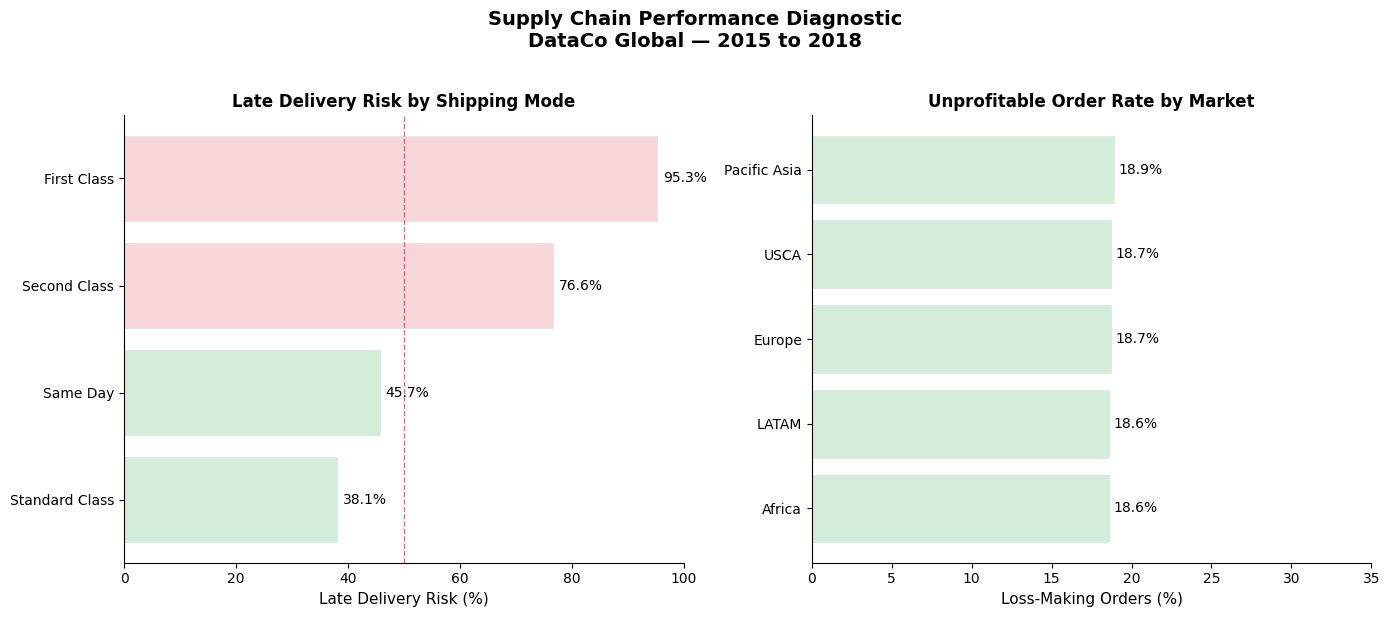

 Chart saved as chart_01_supply_chain_diagnostic.png


In [15]:
# Visualization 1 — Late Delivery by Shipping Mode

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set a clean style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Supply Chain Performance Diagnostic\nDataCo Global — 2015 to 2018',
             fontsize=14, fontweight='bold', y=1.02)

# Chart 1: Late Delivery Rate by Shipping Mode
late_by_mode = df.groupby('Shipping Mode')['late_delivery_risk'].mean() * 100
late_by_mode = late_by_mode.sort_values(ascending=True)

colors = ['#d4edda' if x < 50 else '#f8d7da' for x in late_by_mode.values]

bars = axes[0].barh(late_by_mode.index, late_by_mode.values, color=colors,
                     edgecolor='#dee2e6', linewidth=0.5)
axes[0].axvline(x=50, color='#dc3545', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Late Delivery Risk (%)', fontsize=11)
axes[0].set_title('Late Delivery Risk by Shipping Mode', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 100)

for bar, val in zip(bars, late_by_mode.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)

# Chart 2: Negative Profit Orders by Market
df['is_loss'] = df['Order Profit Per Order'] < 0
loss_by_market = df.groupby('Market').agg(
    total_orders=('Order Id', 'count'),
    loss_orders=('is_loss', 'sum')
).reset_index()
loss_by_market['loss_rate'] = (loss_by_market['loss_orders'] /
                                loss_by_market['total_orders'] * 100).round(1)
loss_by_market = loss_by_market.sort_values('loss_rate', ascending=True)

colors2 = ['#d4edda' if x < 20 else '#fff3cd' if x < 25 else '#f8d7da'
           for x in loss_by_market['loss_rate']]

bars2 = axes[1].barh(loss_by_market['Market'], loss_by_market['loss_rate'],
                      color=colors2, edgecolor='#dee2e6', linewidth=0.5)
axes[1].set_xlabel('Loss-Making Orders (%)', fontsize=11)
axes[1].set_title('Unprofitable Order Rate by Market', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 35)

for bar, val in zip(bars2, loss_by_market['loss_rate']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart_01_supply_chain_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as chart_01_supply_chain_diagnostic.png")

**SUPPLY CHAIN DIAGNOSTIC — KEY FINDINGS**  

FINDING 1: Shipping Mode Reliability Crisis

First Class shipping, the most expensive option, has a 95.3% late delivery rate. Customers paying premium prices are receiving the worst service.

FINDING 2: Systemic Profitability Problem

Loss-making orders hover at 18-19% across ALL markets. This is not a regional issue, it points to a pricing or cost structure problem across the entire business.

FINDING 3: Same Day is the most reliable shipping mode at 45.7% late rate, still high, but best in class relative to other options.

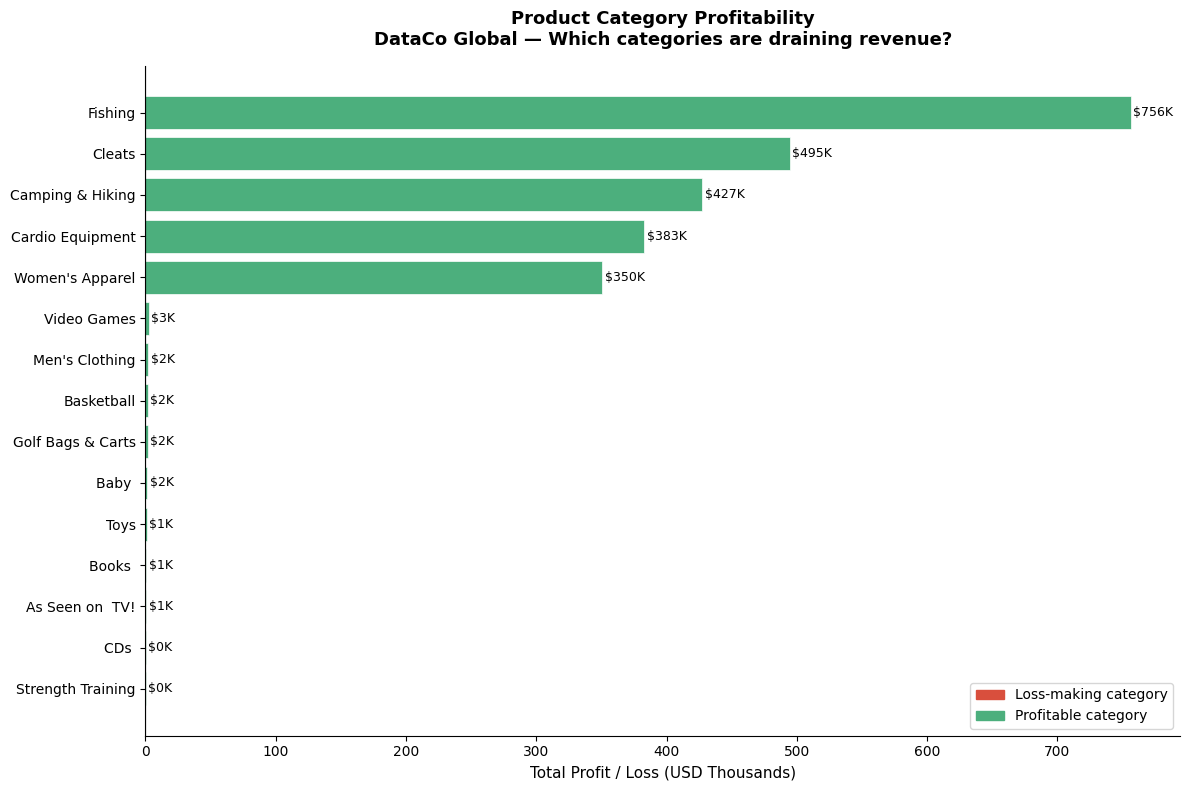

Chart saved as chart_02_category_profitability.png


In [16]:
# CHART 2: Top Loss Making Product Categories

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Calculate profit/loss by product category
category_profit = df.groupby('Category Name').agg(
    total_profit=('Order Profit Per Order', 'sum'),
    order_count=('Order Id', 'count'),
    avg_profit=('Order Profit Per Order', 'mean')
).reset_index()

# Sort by total profit (worst first)
category_profit = category_profit.sort_values('total_profit')

# Take bottom 10 (most loss-making) and top 5 (most profitable)
bottom10 = category_profit.head(10)
top5 = category_profit.tail(5)
plot_data = pd.concat([bottom10, top5]).sort_values('total_profit')

# Color: red for loss, green for profit
colors = ['#d94f3d' if x < 0 else '#4caf7d' for x in plot_data['total_profit']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(plot_data['Category Name'],
               plot_data['total_profit'] / 1000,
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, plot_data['total_profit'] / 1000):
    x_pos = val + (2 if val >= 0 else -2)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}K', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Total Profit / Loss (USD Thousands)', fontsize=11)
ax.set_title('Product Category Profitability\nDataCo Global — Which categories are draining revenue?',
             fontsize=13, fontweight='bold', pad=15)

loss_patch = mpatches.Patch(color='#d94f3d', label='Loss-making category')
profit_patch = mpatches.Patch(color='#4caf7d', label='Profitable category')
ax.legend(handles=[loss_patch, profit_patch], loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_02_category_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart_02_category_profitability.png")

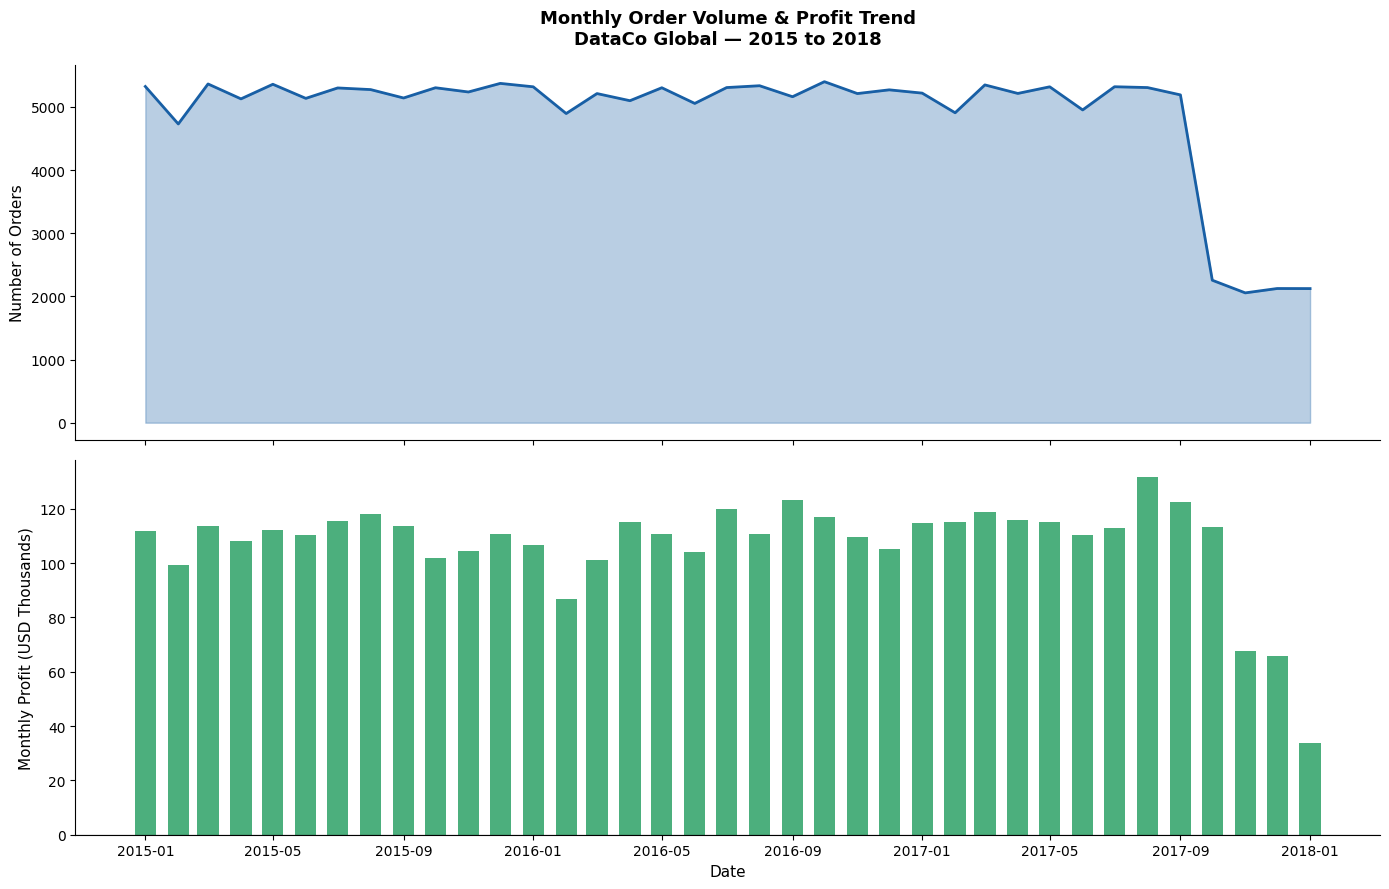

Chart saved as chart_03_monthly_trend.png


In [19]:
# CHART 3: Monthly Order Volume & Revenue Trend Over Tim

# Parse the order date column
df['order_date'] = pd.to_datetime(
    df['order_date'], errors='coerce'
)

# Create year-month column
df['YearMonth'] = df['order_date'].dt.to_period('M')

# Aggregate by month
monthly = df.groupby('YearMonth').agg(
    order_count=('Order Id', 'count'),
    total_sales=('Sales', 'sum'),
    total_profit=('Order Profit Per Order', 'sum')
).reset_index()

monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
monthly = monthly.sort_values('YearMonth_dt')

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top chart — order volume
ax1.fill_between(monthly['YearMonth_dt'], monthly['order_count'],
                 alpha=0.3, color='#185FA5')
ax1.plot(monthly['YearMonth_dt'], monthly['order_count'],
         color='#185FA5', linewidth=2)
ax1.set_ylabel('Number of Orders', fontsize=11)
ax1.set_title('Monthly Order Volume & Profit Trend\nDataCo Global — 2015 to 2018',
              fontsize=13, fontweight='bold', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Bottom chart — monthly profit
colors_profit = ['#d94f3d' if x < 0 else '#4caf7d'
                 for x in monthly['total_profit']]
ax2.bar(monthly['YearMonth_dt'], monthly['total_profit'] / 1000,
        color=colors_profit, width=20)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Monthly Profit (USD Thousands)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_03_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart_03_monthly_trend.png")

**FINAL FINDINGS SUMMARY**

FINDING 1: Shipping reliability is broken at the premium end
First Class shipping has a 95.3% late delivery rate — customers paying the most receive the worst service.

Recommendation: audit First Class carrier contracts or reroute volume to Same Day (45.7% late rate).

FINDING 2: Losses are structural, not product-driven
All product categories are profitable. The ~18.9% loss-making order rate is driven by cost structure (discounting, shipping costs) — not the product mix.

Recommendation: investigate discount approval process.    

FINDING 3: A demand shock hit in late 2017                     
Monthly order volume dropped from ~5,000 to ~2,000 and never recovered. Profit stayed positive, suggesting the business survived but lost significant market share.

Recommendation: Phase 2 forecast will project recovery scenarios and flag at-risk product categories.
